In [1]:
import numpy as np
import gymnasium as gym
import torch
import os
import sys
import matplotlib.pylab as plt

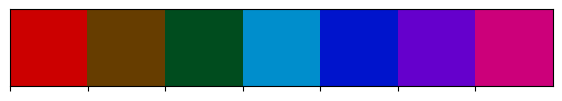

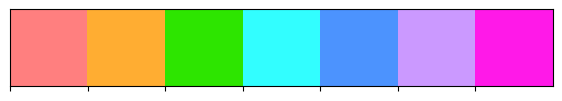

In [2]:
SCRIPT_DIR = os.path.dirname(os.path.abspath("..src"))
sys.path.append(os.path.dirname(SCRIPT_DIR))
from src.replay_buffer import TorchReplayMemory
from src.reward import RewardNet
from src.wrappers.env_wrappers import WallObs, WindowViewObs, MultiChannel
from src.wrappers.monitor_wrappers import BinaryMonitor, RoomMonitor

In [3]:
batch_size = 128
grid_size = [10, 10]
n_mdp_actions = 6
window_size = 11
dryness = 0.05
gamma = 0.99
q_lr = 0.0001
r_lr = 0.0001
bins = 25
center_indx = window_size // 2

device = "mps:0"
n_rows, n_colums = grid_size

main_dir = "../general_models/Plants/reward_model/{}_{}_channel/dry_{}/room/window_{}/q_lr_{}/reward_lr_{}".format(
    n_rows, n_colums, dryness, window_size, q_lr, r_lr,
)

In [4]:
seed = 4
# replay_buffer_1 = TorchReplayMemory(int(1e6))
# replay_buffer_1.load(main_dir + "/checkpoints_{}/".format(1), seed)

# replay_buffer_2 = TorchReplayMemory(int(1e6))
# replay_buffer_2.load(main_dir + "/checkpoints_{}/".format(2), seed)

replay_buffer_3 = TorchReplayMemory(int(1e6))
replay_buffer_3.load(main_dir + "/checkpoints_{}/".format(3), seed)

In [6]:
env = gym.make("gym_monitor/Plants-Watering-v1",
    grid_size=grid_size,
    n_plants=8,
    plants_dryness_prob=dryness,
    dry_difference=0.5,
    agent_start_pos=None,
    max_episode_steps=100,
    render_mode = "human",
    add_new_plants=False,
    add_more_plants=True,
    )

env = WallObs(env, grid_size=grid_size, n_walls=10)
env = WindowViewObs(env, window_size=window_size)
env = MultiChannel(env, normalize_obs=True)
env = RoomMonitor(env, full_monitor=False, monitor_cost=0.0, monitor_column_ind=5)

/Users/montaser/miniconda3/envs/mmdp/lib/python3.11/site-packages/gymnasium/envs/registration.py:787: UserWarning: WARN: The environment is being initialised with render_mode='human' that is not in the possible render_modes ([]).
  logger.warn(
/Users/montaser/miniconda3/envs/mmdp/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:29: UserWarning: WARN: It seems a Box observation space is an image but the `dtype` is not `np.uint8`, actual type: float64. If the Box observation space is not an image, we recommend flattening the observation to have only a 1D vector.
  logger.warn(
/Users/montaser/miniconda3/envs/mmdp/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:34: UserWarning: WARN: It seems a Box observation space is an image but the lower and upper bounds are not [0, 255]. Actual lower bound: 0.0, upper bound: 1.0. Generally, CNN policies assume observations are within that range, so you may encounter an issue if the observation values are not.
 

# plots mean & std

In [5]:
# batch_1 = replay_buffer_1.process_batch(replay_buffer_1.sample(len(replay_buffer_1) -1), device=device)
# unmonitor_ind_1= np.where(batch_1["mon_obs"].cpu().numpy() == 1)[0]
# plant_channels_1 = batch_1["mdp_obs"][unmonitor_ind_1][:, 1:4, center_indx, center_indx].cpu().numpy()

# batch_2 = replay_buffer_2.process_batch(replay_buffer_2.sample(len(replay_buffer_2) -1), device=device)
# unmonitor_ind_2= np.where(batch_2["mon_obs"].cpu().numpy() == 1)[0]
# plant_channels_2 = batch_2["mdp_obs"][unmonitor_ind_2][:, 1:4, center_indx, center_indx].cpu().numpy()

batch_3 = replay_buffer_3.process_batch(replay_buffer_3.sample(len(replay_buffer_3) -1), device=device)
unmonitor_ind_3= np.where(batch_3["mon_obs"].cpu().numpy() == 1)[0]
plant_channels_3 = batch_3["mdp_obs"][unmonitor_ind_3][:, 1:4, center_indx, center_indx].cpu().numpy()

In [6]:
plant_indx = []
cactus_indx = []
diff_1_indx, diff_2_indx, diff_3_indx, diff_4_indx, diff_5_indx = [], [], [], [], []
for i, row in enumerate(plant_channels_3):
    if (row == np.array([0, 1, 1]) / 2).all():
        cactus_indx.append(i)
    if (row == np.array([1, 1, 0]) / 2).all():
        plant_indx.append(i)
    if (row == np.array([0, 0, 1])).all():
        diff_1_indx.append(i)
    if (row == np.array([0, 1, 0])).all():
        diff_2_indx.append(i)
    if (row == np.array([1, 0, 0])).all():
        diff_3_indx.append(i)
    if (row == np.array([1, 0, 1]) / 2).all():
        diff_4_indx.append(i)
    if np.allclose(row , np.array([1, 1, 1]) / 3):
        diff_5_indx.append(i)

len(plant_indx), len(cactus_indx), len(diff_1_indx), len(diff_2_indx), len(diff_3_indx), len(diff_4_indx), len(diff_5_indx)

(74159, 36301, 241, 277, 407, 267, 270)

In [7]:
n_r_models = 500
trained_models = []
for r in range(n_r_models):
    trained_models.append(torch.load(main_dir + "/ensemble_reward_models/reward_model_{}".format(r)))

In [8]:
plants_reward = np.zeros((len(plant_indx), n_r_models, n_mdp_actions))
cactus_reward = np.zeros((len(cactus_indx), n_r_models, n_mdp_actions))
diff_1_reward = np.zeros((len(diff_1_indx), n_r_models, n_mdp_actions))
diff_2_reward = np.zeros((len(diff_2_indx), n_r_models, n_mdp_actions))
diff_3_reward = np.zeros((len(diff_3_indx), n_r_models, n_mdp_actions))
diff_4_reward = np.zeros((len(diff_4_indx), n_r_models, n_mdp_actions))
diff_5_reward = np.zeros((len(diff_5_indx), n_r_models, n_mdp_actions))
for r in range(n_r_models):
    plants_reward[:, r] = trained_models[r]._network(batch_3["mdp_obs"][unmonitor_ind_3][plant_indx][:, :, center_indx, center_indx]).detach().cpu().numpy()
    cactus_reward[:, r] = trained_models[r]._network(batch_3["mdp_obs"][unmonitor_ind_3][cactus_indx][:, :, center_indx, center_indx]).detach().cpu().numpy()
    diff_1_reward[:, r] = trained_models[r]._network(batch_3["mdp_obs"][unmonitor_ind_3][diff_1_indx][:, :, center_indx, center_indx]).detach().cpu().numpy()
    diff_2_reward[:, r] = trained_models[r]._network(batch_3["mdp_obs"][unmonitor_ind_3][diff_2_indx][:, :, center_indx, center_indx]).detach().cpu().numpy()
    diff_3_reward[:, r] = trained_models[r]._network(batch_3["mdp_obs"][unmonitor_ind_3][diff_3_indx][:, :, center_indx, center_indx]).detach().cpu().numpy()
    diff_4_reward[:, r] = trained_models[r]._network(batch_3["mdp_obs"][unmonitor_ind_3][diff_4_indx][:, :, center_indx, center_indx]).detach().cpu().numpy()
    diff_5_reward[:, r] = trained_models[r]._network(batch_3["mdp_obs"][unmonitor_ind_3][diff_5_indx][:, :, center_indx, center_indx]).detach().cpu().numpy()

## Plot Mean & std for Watering each object in Un-monitor room

### Mean

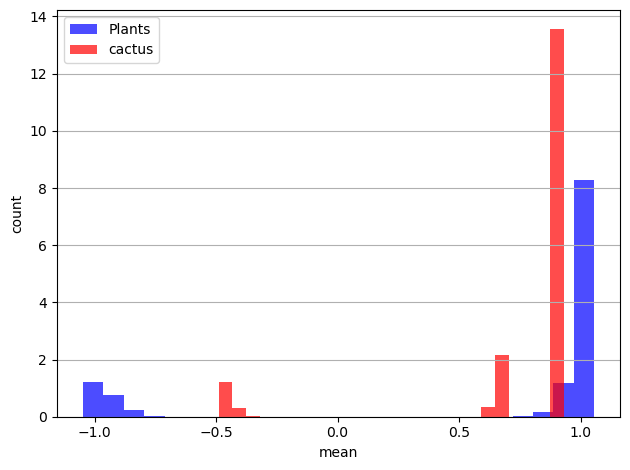

In [9]:
plt.hist(np.mean(plants_reward, 1)[:, 4], density=True, bins=bins, color="b", alpha=0.7, label="Plants")
plt.hist(np.mean(cactus_reward, 1)[:, 4], density=True, bins=bins, color="r", alpha=0.7, label="cactus")
plt.hist(np.mean(diff_1_reward, 1)[:, 4], density=True, bins=bins, color="black", alpha=0.5, label="[0, 0, 1]")
plt.hist(np.mean(diff_2_reward, 1)[:, 4], density=True, bins=bins, color="brown", alpha=0.7, label="[0, 1, 0]")
plt.hist(np.mean(diff_3_reward, 1)[:, 4], density=True, bins=bins, color="orange", alpha=0.7, label="[1, 0, 0]")
plt.hist(np.mean(diff_4_reward, 1)[:, 4], density=True, bins=bins, color="y", alpha=0.7, label="[1, 0, 1]")
plt.hist(np.mean(diff_5_reward, 1)[:, 4], density=True, bins=bins, color="purple", alpha=0.7, label="[1, 1, 1]")
plt.xlabel("mean")
plt.ylabel("count")
plt.grid(axis="y")
plt.legend()
plt.tight_layout()
# plt.savefig(main_dir +"/hist_mean_buffer_3.pdf", dpi=300)

### Std

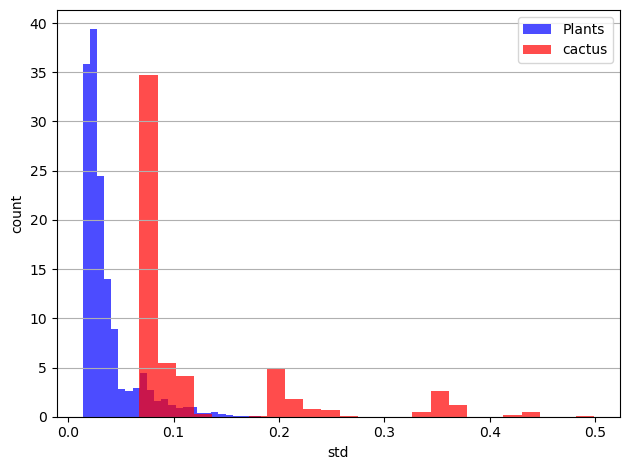

In [10]:
plt.hist(np.std(plants_reward, 1)[:, 4], density=True, bins=bins, color="b", alpha=0.7, label="Plants")
plt.hist(np.std(cactus_reward, 1)[:, 4], density=True, bins=bins, color="r", alpha=0.7, label="cactus")
plt.hist(np.std(diff_1_reward, 1)[:, 4], density=True, bins=bins, color="black", alpha=0.5, label="[0, 0, 1]")
plt.hist(np.std(diff_2_reward, 1)[:, 4], density=True, bins=bins, color="brown", alpha=0.7, label="[0, 1, 0]")
plt.hist(np.std(diff_3_reward, 1)[:, 4], density=True, bins=bins, color="orange", alpha=0.7, label="[1, 0, 0]")
plt.hist(np.std(diff_4_reward, 1)[:, 4], density=True, bins=bins, color="y", alpha=0.7, label="[1, 0, 1]")
plt.hist(np.std(diff_5_reward, 1)[:, 4], density=True, bins=bins, color="purple", alpha=0.7, label="[1, 1, 1]")

plt.xlabel("std")
plt.ylabel("count")
plt.grid(axis="y")
plt.legend()
plt.tight_layout()
# plt.savefig(main_dir +"/hist_std_buffer_3.pdf", dpi=300)

## Single state histogram

In [15]:
dry_value = 0.0
j = np.where(batch_3["mdp_obs"][unmonitor_ind_3][plant_indx][:, 4, center_indx, center_indx].detach().cpu().numpy() == dry_value)[0][0]
p_obs = batch_3["mdp_obs"][unmonitor_ind_3][plant_indx][j][:, center_indx, center_indx]

j = np.where(batch_3["mdp_obs"][unmonitor_ind_3][cactus_indx][:, 4, center_indx, center_indx].detach().cpu().numpy() == dry_value)[0][0]
c_obs = batch_3["mdp_obs"][unmonitor_ind_3][cactus_indx][j][:, center_indx, center_indx]

j = np.where(batch_3["mdp_obs"][unmonitor_ind_3][diff_1_indx][:, 4, center_indx, center_indx].detach().cpu().numpy() == dry_value)[0][0]
d_1_obs = batch_3["mdp_obs"][unmonitor_ind_3][diff_1_indx][j][:, center_indx, center_indx]

j = np.where(batch_3["mdp_obs"][unmonitor_ind_3][diff_2_indx][:, 4, center_indx, center_indx].detach().cpu().numpy() == dry_value)[0][0]
d_2_obs = batch_3["mdp_obs"][unmonitor_ind_3][diff_2_indx][j][:, center_indx, center_indx]

j = np.where(batch_3["mdp_obs"][unmonitor_ind_3][diff_3_indx][:, 4, center_indx, center_indx].detach().cpu().numpy() == dry_value)[0][0]
d_3_obs = batch_3["mdp_obs"][unmonitor_ind_3][diff_3_indx][j][:, center_indx, center_indx]

j = np.where(batch_3["mdp_obs"][unmonitor_ind_3][diff_4_indx][:, 4, center_indx, center_indx].detach().cpu().numpy() == dry_value)[0][0]
d_4_obs = batch_3["mdp_obs"][unmonitor_ind_3][diff_4_indx][j][:, center_indx, center_indx]

j = np.where(batch_3["mdp_obs"][unmonitor_ind_3][diff_5_indx][:, 4, center_indx, center_indx].detach().cpu().numpy() == dry_value)[0][0]
d_5_obs = batch_3["mdp_obs"][unmonitor_ind_3][diff_5_indx][j][:, center_indx, center_indx]

# p_obs[4, center_indx, center_indx].item(), c_obs[4, center_indx, center_indx].item(), d_1_obs[4, center_indx, center_indx].item(), d_2_obs[4, center_indx, center_indx].item(), d_3_obs[4, center_indx, center_indx].item(), d_4_obs[4, center_indx, center_indx].item(), d_5_obs[4, center_indx, center_indx].item()

In [16]:
r_p_obs = np.zeros((n_r_models, n_mdp_actions))
r_c_obs = np.zeros((n_r_models, n_mdp_actions))
r_d_1_obs = np.zeros((n_r_models, n_mdp_actions))
r_d_2_obs = np.zeros((n_r_models, n_mdp_actions))
r_d_3_obs = np.zeros((n_r_models, n_mdp_actions))
r_d_4_obs = np.zeros((n_r_models, n_mdp_actions))
r_d_5_obs = np.zeros((n_r_models, n_mdp_actions))
for r in range(n_r_models):
    r_p_obs[r] = trained_models[r]._network(p_obs.unsqueeze(0)).detach().cpu().numpy()
    r_c_obs[r] = trained_models[r]._network(c_obs.unsqueeze(0)).detach().cpu().numpy()
    r_d_1_obs[r] = trained_models[r]._network(d_1_obs.unsqueeze(0)).detach().cpu().numpy()
    r_d_2_obs[r] = trained_models[r]._network(d_2_obs.unsqueeze(0)).detach().cpu().numpy()
    r_d_3_obs[r] = trained_models[r]._network(d_3_obs.unsqueeze(0)).detach().cpu().numpy()
    r_d_4_obs[r] = trained_models[r]._network(d_4_obs.unsqueeze(0)).detach().cpu().numpy()
    r_d_5_obs[r] = trained_models[r]._network(d_5_obs.unsqueeze(0)).detach().cpu().numpy()

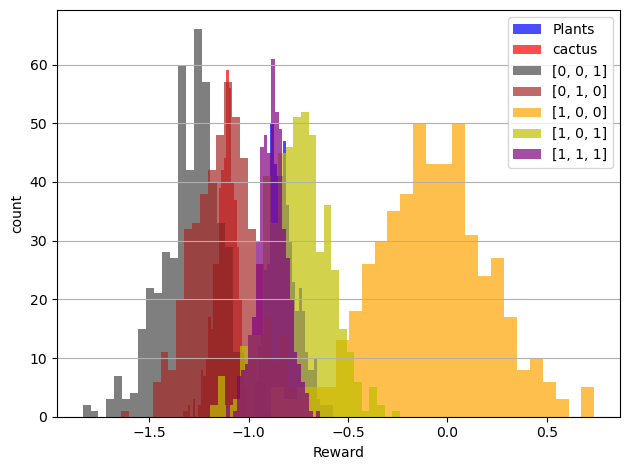

In [17]:
plt.hist(r_p_obs[:, 4], bins=bins, color="b", alpha=0.7, label="Plants")
plt.hist(r_c_obs[:, 4], bins=bins, color="r", alpha=0.7, label="cactus")
plt.hist(r_d_1_obs[:, 4], bins=bins, color="black", alpha=0.5, label="[0, 0, 1]")
plt.hist(r_d_2_obs[:, 4], bins=bins, color="brown", alpha=0.7, label="[0, 1, 0]")
plt.hist(r_d_3_obs[:, 4], bins=bins, color="orange", alpha=0.7, label="[1, 0, 0]")
plt.hist(r_d_4_obs[:, 4], bins=bins, color="y", alpha=0.7, label="[1, 0, 1]")
plt.hist(r_d_5_obs[:, 4], bins=bins, color="purple", alpha=0.7, label="[1, 1, 1]")
plt.xlabel("Reward")
plt.ylabel("count")
plt.grid(axis="y")
plt.legend()
plt.tight_layout()
# plt.savefig(main_dir +"/hist_single_obs_level_{}_buffer_4.pdf".format(dry_value), dpi=300)